# Data Generation

顧客ごとの ID に紐づくユーザーデータを生成します。まずは基本属性として `id`、`gender`、`age`、`frequency`、`amount` を定義します。


In [159]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)


## Parameter Setup

データサイズと生成パラメータをここでまとめて設定します。


In [160]:
SEED = 42
N = 50_000

GENDER_LABELS = ["m", "f"]
# Cosme EC assumption: roughly 20% male / 80% female
GENDER_PROBS = [0.2, 0.8]

AGE_MEAN = 30
AGE_STD = 10
AGE_MIN = 18
AGE_MAX = 70

RECENCY_MEAN = 10
RECENCY_STD = 6
RECENCY_MIN = 0
RECENCY_MAX = 30

FREQUENCY_MEAN = 5
FREQUENCY_LAMBDA = 5

beta0 = 4000
beta1 = 3500
beta2 = 180
amount_age_peak = 40

amount_noise_mean = 0
amount_noise_std = 900

TREATMENT_AGE_MEAN = 20
TREATMENT_AGE_STD = 8
TREATMENT_AMOUNT_STD = 3000
TREATMENT_MAX = 1.0
TREATMENT_RATE_SCALE = 0.75
TREATMENT_NOISE_MEAN = 0
TREATMENT_NOISE_STD = 20
TREATMENT_NOISE_SCALE = 1000

TAU_AGE_MEAN = 35
TAU_AGE_STD = 9
TAU_AMOUNT_STD = 3000
TAU_MAX = 2000

OUTCOME_NOISE_MEAN = 0
OUTCOME_NOISE_STD = 500
rng = np.random.default_rng(SEED)


## Generate User Attributes


In [161]:
amount_noise = np.rint(
    rng.normal(loc=amount_noise_mean, scale=amount_noise_std, size=N)
).astype(int)

user_df = pd.DataFrame(
    {
        "id": np.arange(1, N + 1),
        "gender": rng.choice(GENDER_LABELS, size=N, p=GENDER_PROBS),
    }
)

user_df["age"] = np.clip(
    np.rint(rng.normal(loc=AGE_MEAN, scale=AGE_STD, size=N)),
    AGE_MIN,
    AGE_MAX,
).astype(int)

user_df["recency"] = np.clip(
    np.rint(rng.normal(loc=RECENCY_MEAN, scale=RECENCY_STD, size=N)),
    RECENCY_MIN,
    RECENCY_MAX,
).astype(int)

user_df["frequency"] = rng.poisson(lam=FREQUENCY_LAMBDA, size=N).astype(int)

user_df["amount"] = (
    beta0
    + beta1 * np.sqrt(user_df["frequency"])
    - beta2 * ((user_df["age"] - amount_age_peak) ** 2) / 100
    + amount_noise
).astype(int)

user_df.head()


,id,gender,age,recency,frequency,amount
0,1,m,23,7,5,11580
1,2,f,28,22,6,11378
2,3,f,21,14,3,10087
3,4,f,32,10,5,12558
4,5,m,35,3,4,9199


In [162]:
user_df.describe(include="all")


,id,gender,age,recency,frequency,amount
count,50000.000000,50000,50000.00000,50000.000000,50000.000000,50000.000000
unique,NaN,2,NaN,NaN,NaN,NaN
top,NaN,m,NaN,NaN,NaN,NaN
freq,NaN,29930,NaN,NaN,NaN,NaN
mean,25000.500000,NaN,30.54422,10.153700,4.987400,11282.924280
std,14433.901067,NaN,9.08917,5.753303,2.217706,2081.674725
min,1.000000,NaN,18.00000,0.000000,0.000000,1098.000000
25%,12500.750000,NaN,23.00000,6.000000,3.000000,9971.000000
50%,25000.500000,NaN,30.00000,10.000000,5.000000,11356.000000
75%,37500.250000,NaN,37.00000,14.000000,6.000000,12685.250000


## Generate Treatment Rate And Effect

`treatment_rate` は介入率、`tau` は介入効果です。どちらも `age` と `amount` に依存する分布ベースで生成します。


In [163]:
amount_mean = user_df["amount"].mean()
amount_q25 = user_df["amount"].quantile(0.25)

tau_age_score = np.exp(-0.5 * ((user_df["age"] - TAU_AGE_MEAN) / TAU_AGE_STD) ** 2)
tau_amount_score = np.exp(-0.5 * ((user_df["amount"] - amount_q25) / TAU_AMOUNT_STD) ** 2)
tau_base = tau_age_score * tau_amount_score
tau_base = tau_base / tau_base.max()
user_df["tau"] = np.clip(
    TAU_MAX * tau_base,
    0,
    TAU_MAX,
).astype(int)

user_df[["id", "age", "amount", "tau"]].head()


,id,age,amount,tau
0,1,23,11580,712
1,2,28,11378,1324
2,3,21,10087,596
3,4,32,12558,1304
4,5,35,9199,1934


In [164]:
treatment_age_score = np.exp(-0.5 * ((user_df["age"] - TREATMENT_AGE_MEAN) / TREATMENT_AGE_STD) ** 2)
treatment_amount_score = np.exp(-0.5 * ((user_df["amount"] - amount_mean) / TREATMENT_AMOUNT_STD) ** 2)
treatment_base = treatment_age_score * treatment_amount_score
treatment_base = treatment_base / treatment_base.max()
treatment_noise = np.rint(
    rng.normal(loc=TREATMENT_NOISE_MEAN, scale=TREATMENT_NOISE_STD, size=N)
).astype(int)

user_df["treatment_rate"] = np.clip(
    TREATMENT_RATE_SCALE * TREATMENT_MAX * treatment_base + treatment_noise / TREATMENT_NOISE_SCALE,
    0,
    TREATMENT_MAX,
)

user_df[["id", "age", "amount", "tau", "treatment_rate"]].head()


,id,age,amount,tau,treatment_rate
0,1,23,11580,712,0.686658
1,2,28,11378,1324,0.442670
2,3,21,10087,596,0.677323
3,4,32,12558,1304,0.227461
4,5,35,9199,1934,0.086595


In [165]:
user_df["treatment"] = rng.binomial(n=1, p=user_df["treatment_rate"]).astype(int)

treatment_count_df = (
    user_df["treatment"]
    .value_counts()
    .sort_index()
    .rename_axis("treatment")
    .reset_index(name="count")
)

display(treatment_count_df)
print("treatment rate mean:", user_df["treatment_rate"].mean())
print("treated share:", user_df["treatment"].mean())


,treatment,count
0,0,34549
1,1,15451


treatment rate mean: 0.30731701911501935
treated share: 0.30902


In [166]:
user_df["y0"] = user_df["amount"].astype(int)
user_df["y1"] = (user_df["y0"] + user_df["tau"]).astype(int)

outcome_noise = np.rint(
    rng.normal(loc=OUTCOME_NOISE_MEAN, scale=OUTCOME_NOISE_STD, size=N)
).astype(int)

user_df["outcome"] = np.where(
    user_df["treatment"] == 1,
    user_df["y1"],
    user_df["y0"],
)
user_df["outcome"] = np.clip(user_df["outcome"] + outcome_noise, 0, None).astype(int)

user_df[["id", "amount", "tau", "y0", "y1", "treatment", "outcome"]].head()


,id,amount,tau,y0,y1,treatment,outcome
0,1,11580,712,11580,12292,1,12196
1,2,11378,1324,11378,12702,1,12717
2,3,10087,596,10087,10683,1,10820
3,4,12558,1304,12558,13862,0,13480
4,5,9199,1934,9199,11133,1,10626


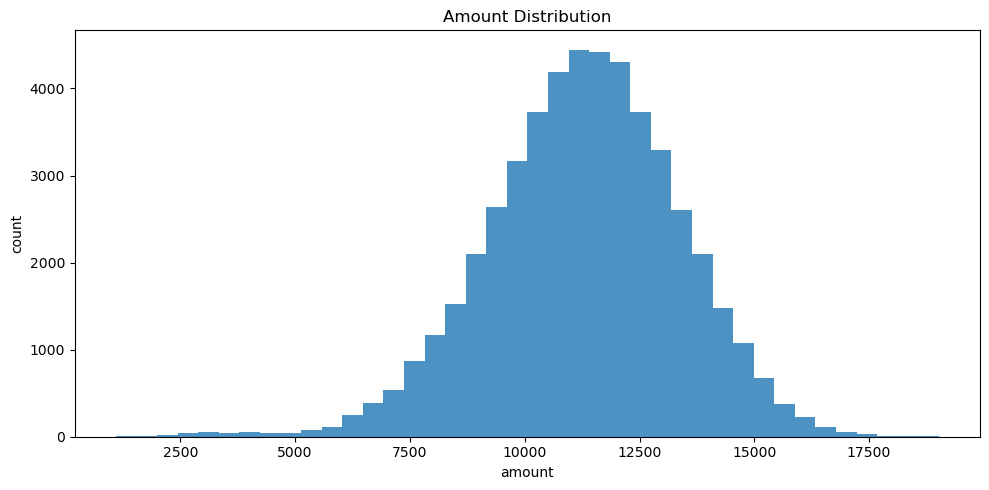

In [167]:
plt.figure(figsize=(10, 5))
plt.hist(user_df["amount"], bins=40, alpha=0.8)
plt.title("Amount Distribution")
plt.xlabel("amount")
plt.ylabel("count")
plt.tight_layout()
plt.show()


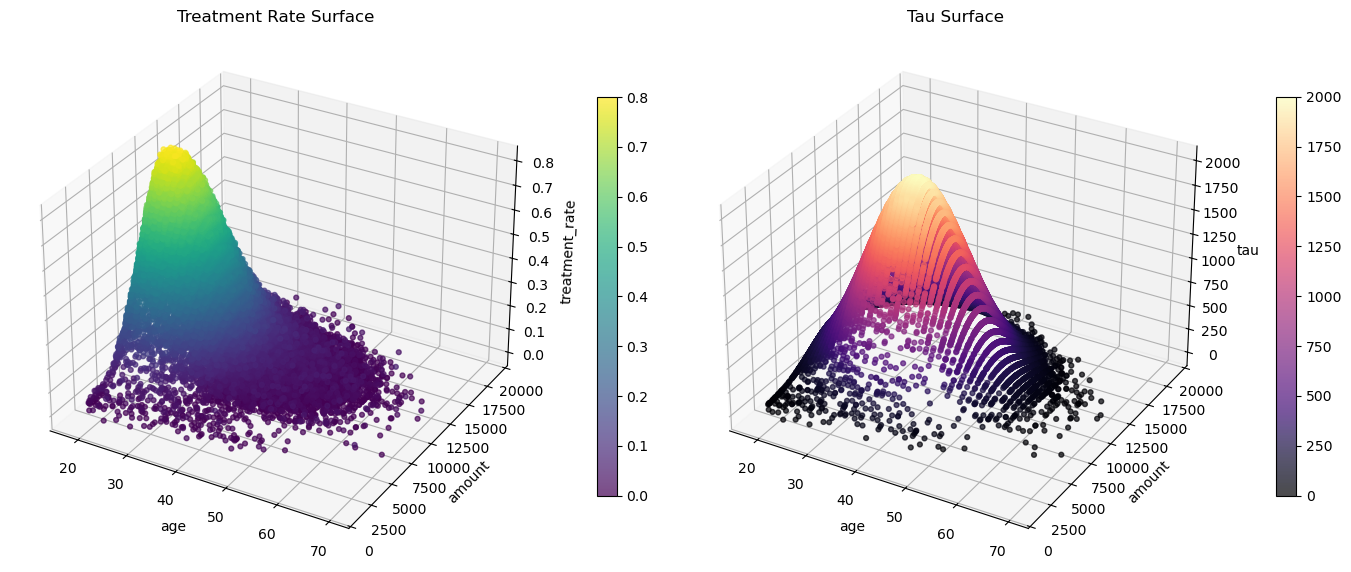

In [168]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
scatter1 = ax1.scatter(
    user_df["age"],
    user_df["amount"],
    user_df["treatment_rate"],
    c=user_df["treatment_rate"],
    cmap="viridis",
    s=12,
    alpha=0.7,
)
ax1.set_title("Treatment Rate Surface")
ax1.set_xlabel("age")
ax1.set_ylabel("amount")
ax1.set_zlabel("treatment_rate")
fig.colorbar(scatter1, ax=ax1, shrink=0.7, pad=0.08)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter2 = ax2.scatter(
    user_df["age"],
    user_df["amount"],
    user_df["tau"],
    c=user_df["tau"],
    cmap="magma",
    s=12,
    alpha=0.7,
)
ax2.set_title("Tau Surface")
ax2.set_xlabel("age")
ax2.set_ylabel("amount")
ax2.set_zlabel("tau")
fig.colorbar(scatter2, ax=ax2, shrink=0.7, pad=0.08)

plt.tight_layout()
plt.show()


In [169]:
user_df

,id,gender,age,recency,frequency,amount,tau,treatment_rate,treatment,y0,y1,outcome
0,1,m,23,7,5,11580,712,0.686658,1,11580,12292,12196
1,2,f,28,22,6,11378,1324,0.442670,1,11378,12702,12717
2,3,f,21,14,3,10087,596,0.677323,1,10087,10683,10820
3,4,f,32,10,5,12558,1304,0.227461,0,12558,13862,13480
4,5,m,35,3,4,9199,1934,0.086595,1,9199,11133,10626
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,f,27,8,2,8901,1264,0.399181,0,8901,10165,8778
49996,49997,m,25,18,6,13809,475,0.469792,1,13809,14284,13852
49997,49998,f,39,14,2,9306,1767,0.047968,0,9306,11073,9784
49998,49999,m,24,18,7,14021,380,0.435405,1,14021,14401,14375


In [170]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

csv_path = DATA_DIR / "sampledata_coupon.csv"
parquet_path = DATA_DIR / "sampledata_coupon.parquet"

user_df.to_csv(csv_path, index=False)
user_df.to_parquet(parquet_path, index=False)

print(f"saved csv: {csv_path}")
print(f"saved parquet: {parquet_path}")


saved csv: data/sampledata_coupon.csv
saved parquet: data/sampledata_coupon.parquet
